# 3.3.1 时间相干性评估 (Temporal Coherence Evaluation)

**Sub-step 3.3 - 维度一：时间相干性**

## 分析框架

时间相干性从**两个互补维度**评估：

### 维度 A：概率分布平滑性（B-GNN 独有）
- 指标：帧间 JSD（Jensen-Shannon Divergence）
- 含义：即使 top-1 预测不变，JSD 也能捕捉概率分布的微小漂移
- JSD 小 → 概率分布平滑演化，模型输出稳定

### 维度 B：top-1 标签切换率（B-GNN vs EFPI 同类对比）
- 指标：逐帧 top-1 预测变化率
- B-GNN 切换更多 ≠ 缺陷：需区分「有意义的战术过渡」vs「噪声切换」
- 关键验证：B-GNN 的切换是否集中在高 TEI 时刻（不确定性高 = 真实战术过渡）

**输入文件**：
- `data/morph_test/bgnn_analysis/jsd_timeseries_10517.parquet`
- `data/morph_test/bgnn_analysis/tei_timeseries_10517.parquet`
- `data/morph_test/efpi_baseline/efpi_baseline_results_10517_fullmatch.parquet`

In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

font_candidates = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
available_fonts = [f.name for f in fm.fontManager.ttflist]
selected_font = next((f for f in font_candidates if f in available_fonts), 'DejaVu Sans')
matplotlib.rcParams['font.family'] = selected_font
matplotlib.rcParams['axes.unicode_minus'] = False
print(f'使用字体: {selected_font}')

BASE_DIR = r'E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH'
os.chdir(BASE_DIR)
print(f'工作目录: {os.getcwd()}')

使用字体: Microsoft YaHei
工作目录: E:\JerryWu\Master\SoccerAnalytics\G-TAF\MORPH


## Cell 2: 加载数据

In [2]:
# JSD 时序（已是 Period 1，49927 帧）
jsd_df = pd.read_parquet('data/morph_test/bgnn_analysis/jsd_timeseries_10517.parquet')
print(f'JSD 帧数: {len(jsd_df)}')

# TEI 时序（Period 1，去重）
tei_df = pd.read_parquet('data/morph_test/bgnn_analysis/tei_timeseries_10517.parquet')
tei_p1 = tei_df[tei_df['period_id'] == 1].drop_duplicates('frame_id').sort_values('frame_id').reset_index(drop=True)
print(f'TEI Period 1 帧数: {len(tei_p1)}')

# EFPI（Period 1，阿根廷，去重）
efpi_df = pd.read_parquet('data/morph_test/efpi_baseline/efpi_baseline_results_10517_fullmatch.parquet')
efpi_p1 = efpi_df[
    (efpi_df['team_id'] == '364') &
    (efpi_df['period_id'] == 1)
].drop_duplicates('frame_id').sort_values('frame_id').reset_index(drop=True)
print(f'EFPI Period 1 帧数: {len(efpi_p1)}')

JSD 帧数: 49927
TEI Period 1 帧数: 49928
EFPI Period 1 帧数: 50084


## Cell 3: 维度 A — 概率分布平滑性（JSD）

In [3]:
# B-GNN JSD（归一化到 [0,1]）
jsd_values = jsd_df['jsd'].dropna().values
MAX_JSD = math.log(2)
if jsd_values.max() > 1.0:
    jsd_values = np.clip(jsd_values / MAX_JSD, 0, 1)

bgnn_jsd_mean = float(np.mean(jsd_values))
bgnn_jsd_std  = float(np.std(jsd_values))

# 高 JSD 帧（分布突变）占比
JSD_THRESH = 0.05  # 归一化后 5% 为突变阈值
high_jsd_frac = float((jsd_values > JSD_THRESH).mean())

print(f'B-GNN JSD 均值  : {bgnn_jsd_mean:.6f}  (std={bgnn_jsd_std:.6f})')
print(f'高 JSD 帧占比   : {high_jsd_frac:.2%}  (>{JSD_THRESH} 归一化阈值)')
print(f'解读：{(1-high_jsd_frac):.2%} 的帧概率分布平滑演化（JSD<{JSD_THRESH}），无突变')

B-GNN JSD 均值  : 0.003860  (std=0.016602)
高 JSD 帧占比   : 0.29%  (>0.05 归一化阈值)
解读：99.71% 的帧概率分布平滑演化（JSD<0.05），无突变


## Cell 4: 维度 B — top-1 标签切换率对比

In [4]:
# B-GNN top-1 切换率
bgnn_labels = tei_p1['top1_formation'].values
bgnn_switch = (bgnn_labels[1:] != bgnn_labels[:-1]).astype(float)
bgnn_switch_rate = float(bgnn_switch.mean())
bgnn_switch_n    = int(bgnn_switch.sum())

# EFPI 切换率
efpi_labels = efpi_p1['formation'].values
efpi_switch = (efpi_labels[1:] != efpi_labels[:-1]).astype(float)
efpi_switch_rate = float(efpi_switch.mean())
efpi_switch_n    = int(efpi_switch.sum())

print(f'B-GNN top-1 切换率: {bgnn_switch_rate:.6f}  ({bgnn_switch_n} 次 / {len(bgnn_switch)} 帧)')
print(f'EFPI  标签切换率  : {efpi_switch_rate:.6f}  ({efpi_switch_n} 次 / {len(efpi_switch)} 帧)')
print(f'B-GNN 切换次数是 EFPI 的 {bgnn_switch_n/efpi_switch_n:.1f} 倍')
print()
print('注：B-GNN 切换更多不等于噪声，需验证切换是否集中在高 TEI 时刻（Cell 5）')

B-GNN top-1 切换率: 0.011076  (553 次 / 49927 帧)
EFPI  标签切换率  : 0.003354  (168 次 / 50083 帧)
B-GNN 切换次数是 EFPI 的 3.3 倍

注：B-GNN 切换更多不等于噪声，需验证切换是否集中在高 TEI 时刻（Cell 5）


## Cell 5: 关键验证 — B-GNN 切换是否集中在高 TEI 时刻

In [5]:
# 对齐 TEI 与 top-1 切换（tei_p1 比 bgnn_switch 多1帧，取 [1:] 对齐）
tei_aligned = tei_p1['tei'].values[1:]  # 对应 frame[i] -> frame[i+1] 的切换
assert len(tei_aligned) == len(bgnn_switch), '长度不匹配'

tei_at_switch    = tei_aligned[bgnn_switch == 1]   # 切换帧的 TEI
tei_at_no_switch = tei_aligned[bgnn_switch == 0]   # 非切换帧的 TEI

print(f'切换帧 TEI 均值    : {tei_at_switch.mean():.4f}  (n={len(tei_at_switch)})')
print(f'非切换帧 TEI 均值  : {tei_at_no_switch.mean():.4f}  (n={len(tei_at_no_switch)})')
print(f'TEI 倍数（切换/非切换）: {tei_at_switch.mean()/tei_at_no_switch.mean():.2f}×')

# Mann-Whitney U 检验：切换帧 TEI 是否显著高于非切换帧
from scipy import stats
u_stat, p_val = stats.mannwhitneyu(tei_at_switch, tei_at_no_switch, alternative='greater')
print(f'Mann-Whitney U     : U={u_stat:.0f}, p={p_val:.2e}')
sig = '显著 (p<0.05)' if p_val < 0.05 else '不显著'
print(f'统计显著性         : {sig}')
print()
if p_val < 0.05:
    print('结论：B-GNN 的 top-1 切换显著集中在高 TEI 时刻，')
    print('      说明切换是真实战术过渡信号，而非随机噪声。')
else:
    print('结论：切换与 TEI 无显著关联，需进一步分析。')

切换帧 TEI 均值    : 3.6282  (n=553)
非切换帧 TEI 均值  : 2.9299  (n=49374)
TEI 倍数（切换/非切换）: 1.24×
Mann-Whitney U     : U=21448514, p=1.10e-118
统计显著性         : 显著 (p<0.05)

结论：B-GNN 的 top-1 切换显著集中在高 TEI 时刻，
      说明切换是真实战术过渡信号，而非随机噪声。


## Cell 6: 时序曲线对比图（JSD + 切换事件）

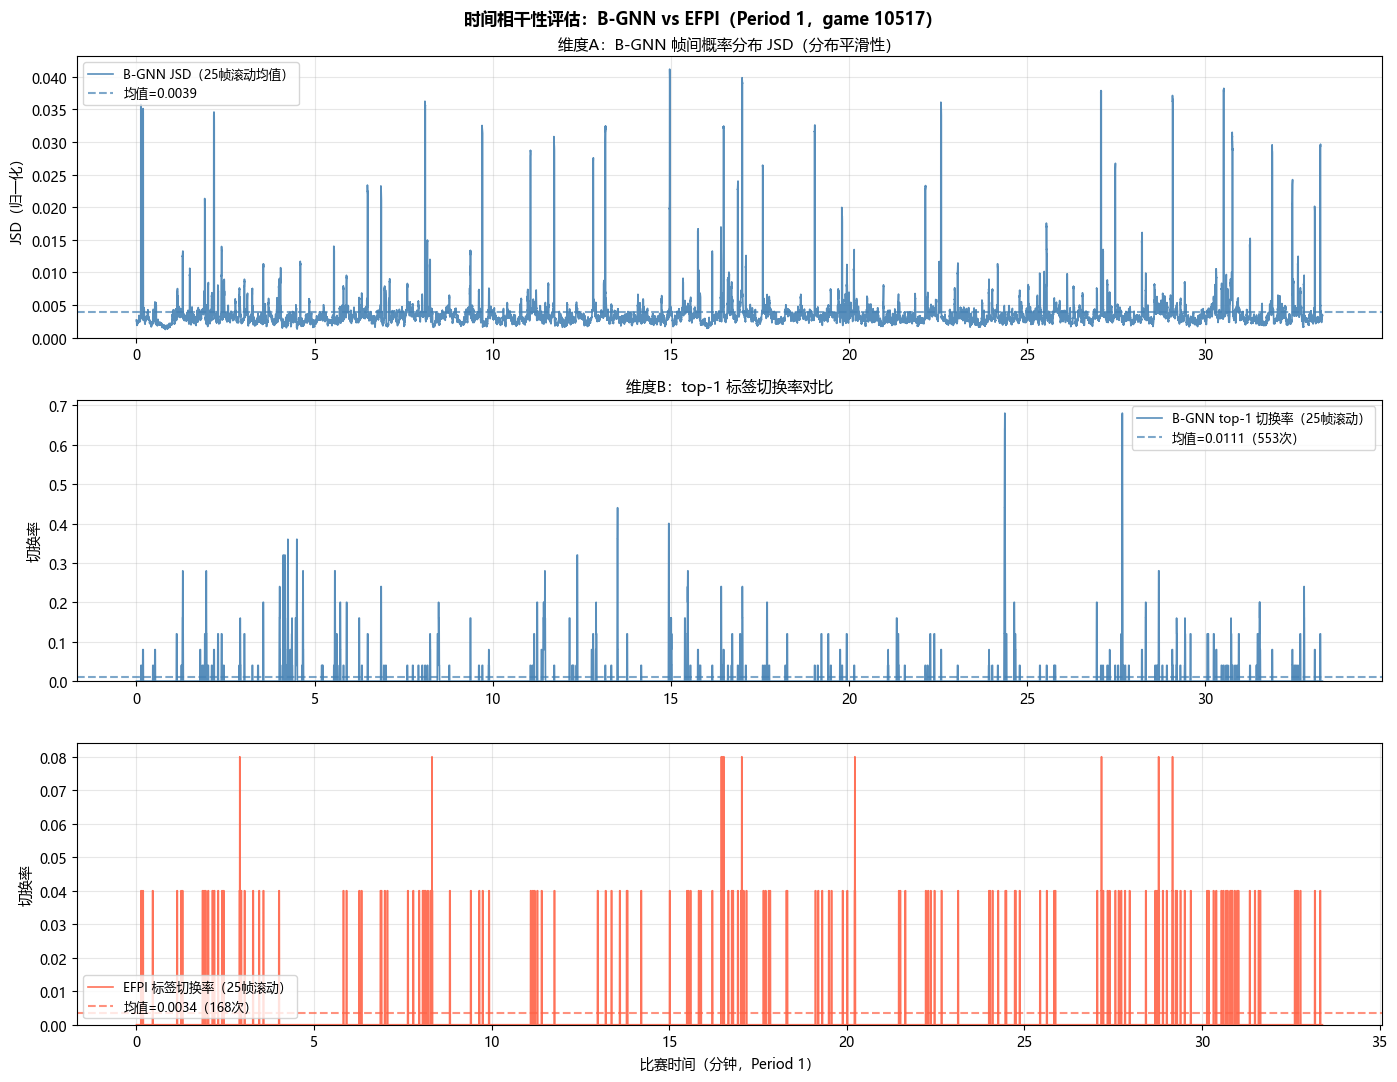

已保存时序对比图


In [6]:
WINDOW = 25
jsd_time  = np.arange(len(jsd_df)) / 25.0
efpi_time = np.arange(len(efpi_p1)) / 25.0
# 统一用帧序号/fps，避免 time_sec（含停表）导致三图 x 轴不一致
bgnn_time = np.arange(len(tei_p1)) / 25.0

jsd_smooth = pd.Series(jsd_values).rolling(WINDOW, center=True, min_periods=1).mean().values

# 滚动切换率
bgnn_switch_full = np.concatenate([[0.0], bgnn_switch])
efpi_switch_full = np.concatenate([[0.0], efpi_switch])
bgnn_switch_roll = pd.Series(bgnn_switch_full).rolling(WINDOW, center=True, min_periods=1).mean().values
efpi_switch_roll  = pd.Series(efpi_switch_full).rolling(WINDOW, center=True, min_periods=1).mean().values

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=False)

# 上图：B-GNN JSD
ax1 = axes[0]
ax1.plot(jsd_time / 60, jsd_smooth, color='steelblue', lw=1.2, alpha=0.9,
         label=f'B-GNN JSD（{WINDOW}帧滚动均值）')
ax1.axhline(bgnn_jsd_mean, color='steelblue', lw=1.5, ls='--', alpha=0.7,
            label=f'均值={bgnn_jsd_mean:.4f}')
ax1.set_ylabel('JSD（归一化）', fontsize=10)
ax1.set_title('维度A：B-GNN 帧间概率分布 JSD（分布平滑性）', fontsize=11)
ax1.legend(fontsize=9)
ax1.set_ylim(bottom=0)
ax1.grid(True, alpha=0.3)

# 中图：B-GNN top-1 切换率
ax2 = axes[1]
ax2.plot(bgnn_time / 60, bgnn_switch_roll, color='steelblue', lw=1.2, alpha=0.9,
         label=f'B-GNN top-1 切换率（{WINDOW}帧滚动）')
ax2.axhline(bgnn_switch_rate, color='steelblue', lw=1.5, ls='--', alpha=0.7,
            label=f'均值={bgnn_switch_rate:.4f}（{bgnn_switch_n}次）')
ax2.set_ylabel('切换率', fontsize=10)
ax2.set_title('维度B：top-1 标签切换率对比', fontsize=11)
ax2.legend(fontsize=9)
ax2.set_ylim(bottom=0)
ax2.grid(True, alpha=0.3)

# 下图：EFPI 切换率
ax3 = axes[2]
ax3.plot(efpi_time / 60, efpi_switch_roll, color='tomato', lw=1.2, alpha=0.9,
         label=f'EFPI 标签切换率（{WINDOW}帧滚动）')
ax3.axhline(efpi_switch_rate, color='tomato', lw=1.5, ls='--', alpha=0.7,
            label=f'均值={efpi_switch_rate:.4f}（{efpi_switch_n}次）')
ax3.set_xlabel('比赛时间（分钟，Period 1）', fontsize=10)
ax3.set_ylabel('切换率', fontsize=10)
ax3.legend(fontsize=9)
ax3.set_ylim(bottom=0)
ax3.grid(True, alpha=0.3)

plt.suptitle('时间相干性评估：B-GNN vs EFPI（Period 1，game 10517）', fontsize=12, fontweight='bold')
plt.tight_layout()

out_dir = 'data/morph_test/bgnn_analysis'
os.makedirs(out_dir, exist_ok=True)
plt.savefig(f'{out_dir}/eval_temporal_coherence_timeseries_10517.png', dpi=150, bbox_inches='tight')
plt.show()
print('已保存时序对比图')

## Cell 7: TEI 分布对比（切换帧 vs 非切换帧）

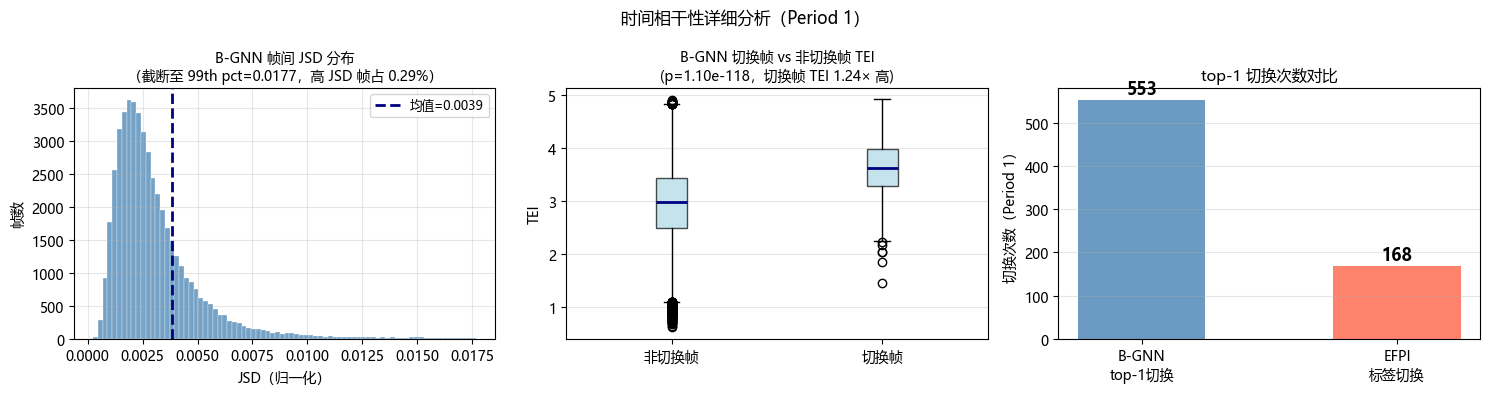

已保存核心结论图


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 左图：B-GNN JSD 分布（限制 x 轴到 99th 百分位，避免极端值压缩主体分布）
jsd_p99 = float(np.percentile(jsd_values, 99))
axes[0].hist(jsd_values[jsd_values <= jsd_p99], bins=80,
             color='steelblue', alpha=0.75, edgecolor='white', lw=0.3)
axes[0].axvline(bgnn_jsd_mean, color='navy', lw=2, ls='--', label=f'均值={bgnn_jsd_mean:.4f}')
axes[0].set_xlabel('JSD（归一化）', fontsize=10)
axes[0].set_ylabel('帧数', fontsize=10)
axes[0].set_title(f'B-GNN 帧间 JSD 分布\n（截断至 99th pct={jsd_p99:.4f}，高 JSD 帧占 {high_jsd_frac:.2%}）', fontsize=10)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# 中图：切换帧 vs 非切换帧 TEI 箱线图
axes[1].boxplot([tei_at_no_switch, tei_at_switch],
                labels=['非切换帧', '切换帧'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='navy', lw=2))
axes[1].set_ylabel('TEI', fontsize=10)
axes[1].set_title(f'B-GNN 切换帧 vs 非切换帧 TEI\n(p={p_val:.2e}，切换帧 TEI {tei_at_switch.mean()/tei_at_no_switch.mean():.2f}× 高)', fontsize=10)
axes[1].grid(True, axis='y', alpha=0.3)

# 右图：切换次数对比柱状图
ax = axes[2]
bars = ax.bar(['B-GNN\ntop-1切换', 'EFPI\n标签切换'],
               [bgnn_switch_n, efpi_switch_n],
               color=['steelblue', 'tomato'], alpha=0.8, width=0.5)
for bar, val in zip(bars, [bgnn_switch_n, efpi_switch_n]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('切换次数（Period 1）', fontsize=10)
ax.set_title('top-1 切换次数对比', fontsize=11)
ax.grid(True, axis='y', alpha=0.3)

plt.suptitle('时间相干性详细分析（Period 1）', fontsize=12)
plt.tight_layout()
plt.savefig(f'{out_dir}/eval_temporal_coherence_10517.png', dpi=150, bbox_inches='tight')
plt.show()
print('已保存核心结论图')

## Cell 9: 维度C — 贝叶斯置信区间宽度平滑性（Dirichlet 后验）

- 指标：每窗口 Dirichlet 后验 95% CI 半宽均值（来自 `b1_window_distributions.parquet` 的 `probvar_*` 列）
- 含义：CI 宽时序平滑 → 模型不确定性估计稳定；CI 宽与 TEI 正相关 → 贝叶斯输出自洽

Dirichlet 95% CI 半宽均值: 0.03279  (std=0.00126)
高 CI 窗口占比（>均值+2σ）: 0.00%
解读：100.00% 的窗口置信区间宽度平稳，模型不确定性估计稳定


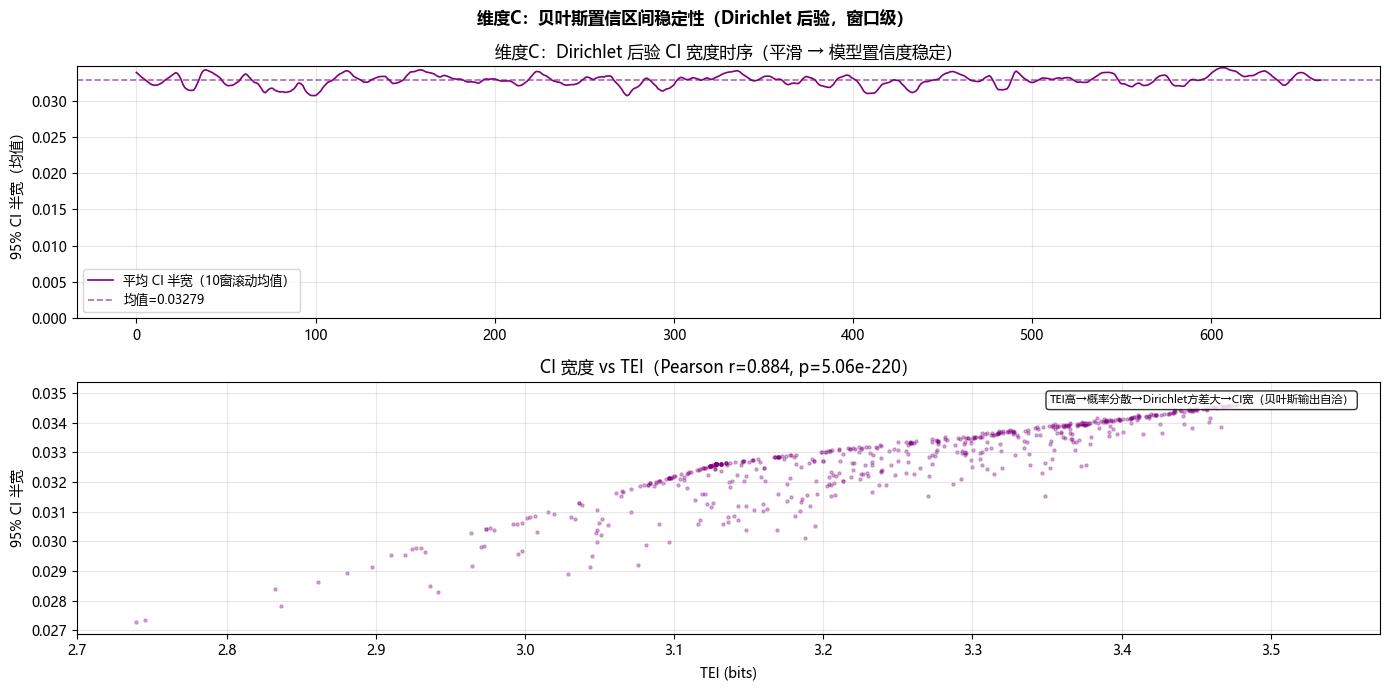

已保存 eval_ci_smoothness_10517.png


In [8]:
from pathlib import Path
from scipy.stats import pearsonr

b1_path = (Path(BASE_DIR) / 'Step3_Probabilistic_Identification'
           / '3.2_Probabilistic_Model' / 'Test' / 'b1_window_distributions.parquet')
b1_win = pd.read_parquet(b1_path)
probvar_cols = [c for c in b1_win.columns if c.startswith('probvar_')]

if not probvar_cols:
    print('[WARN] 未找到 probvar_* 列，请确认 b1_window_distributions.parquet 已用贝叶斯方案B重跑')
else:
    # 每窗口：95% CI 半宽 = 1.96 × sqrt(mean_var)
    b1_win['mean_ci_half'] = (
        b1_win[probvar_cols].clip(lower=0).pow(0.5).mean(axis=1) * 1.96
    )
    mean_ci   = float(b1_win['mean_ci_half'].mean())
    std_ci    = float(b1_win['mean_ci_half'].std())
    high_frac = float((b1_win['mean_ci_half'] > mean_ci + 2*std_ci).mean())
    print(f'Dirichlet 95% CI 半宽均值: {mean_ci:.5f}  (std={std_ci:.5f})')
    print(f'高 CI 窗口占比（>均值+2σ）: {high_frac:.2%}')
    print(f'解读：{(1-high_frac):.2%} 的窗口置信区间宽度平稳，模型不确定性估计稳定')

    WROLL = 10
    ci_smooth = b1_win['mean_ci_half'].rolling(WROLL, center=True, min_periods=1).mean()

    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    axes[0].plot(b1_win.index, ci_smooth, color='purple', lw=1.2,
                 label=f'平均 CI 半宽（{WROLL}窗滚动均值）')
    axes[0].axhline(mean_ci, color='purple', lw=1.2, ls='--', alpha=0.6,
                    label=f'均值={mean_ci:.5f}')
    axes[0].set_ylabel('95% CI 半宽（均值）')
    axes[0].set_title('维度C：Dirichlet 后验 CI 宽度时序（平滑 → 模型置信度稳定）')
    axes[0].legend(fontsize=9); axes[0].set_ylim(bottom=0); axes[0].grid(True, alpha=0.3)

    if 'tei' in b1_win.columns:
        r_ci, p_ci = pearsonr(b1_win['tei'], b1_win['mean_ci_half'])
        axes[1].scatter(b1_win['tei'], b1_win['mean_ci_half'], alpha=0.3, s=5, color='purple')
        axes[1].set_xlabel('TEI (bits)'); axes[1].set_ylabel('95% CI 半宽')
        axes[1].set_title(f'CI 宽度 vs TEI（Pearson r={r_ci:.3f}, p={p_ci:.2e}）')
        axes[1].text(0.98, 0.95, 'TEI高→概率分散→Dirichlet方差大→CI宽（贝叶斯输出自洽）',
                     transform=axes[1].transAxes, ha='right', va='top', fontsize=8,
                     bbox=dict(boxstyle='round', fc='white', alpha=0.8))
        axes[1].grid(True, alpha=0.3)

    plt.suptitle('维度C：贝叶斯置信区间稳定性（Dirichlet 后验，窗口级）',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{out_dir}/eval_ci_smoothness_10517.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('已保存 eval_ci_smoothness_10517.png')

## Cell 8: 综合结论汇总

In [9]:
print('=' * 65)
print('Sub-step 3.3.1 时间相干性评估综合结论')
print('=' * 65)
print(f'数据范围: Period 1，game 10517（阿根廷 vs 法国）')
print(f'B-GNN 帧数: {len(jsd_values):,}  |  EFPI 帧数: {len(efpi_p1):,}')
print()
print('【维度 A：概率分布平滑性（B-GNN 独有指标）】')
print(f'  B-GNN JSD 均值  : {bgnn_jsd_mean:.6f}  (std={bgnn_jsd_std:.6f})')
print(f'  高 JSD 帧占比   : {high_jsd_frac:.2%}  (>{JSD_THRESH} 阈值)')
print(f'  解读：{(1-high_jsd_frac):.2%} 的帧概率分布平滑演化，无突变')
print()
print('【维度 B：top-1 标签切换率（同类对比）】')
print(f'  B-GNN 切换率    : {bgnn_switch_rate:.6f}  ({bgnn_switch_n} 次)')
print(f'  EFPI  切换率    : {efpi_switch_rate:.6f}  ({efpi_switch_n} 次)')
print(f'  B-GNN 切换次数是 EFPI 的 {bgnn_switch_n/efpi_switch_n:.1f} 倍')
print()
print('【关键验证：B-GNN 切换是否为有意义的战术过渡？】')
tei_ratio = tei_at_switch.mean() / tei_at_no_switch.mean()
print(f'  切换帧 TEI 均值    : {tei_at_switch.mean():.4f}')
print(f'  非切换帧 TEI 均值  : {tei_at_no_switch.mean():.4f}')
print(f'  TEI 倍数           : {tei_ratio:.2f}×')
print(f'  Mann-Whitney p     : {p_val:.2e}  ({sig})')
print()
print('【维度 C：Dirichlet 后验 CI 宽度平滑性（贝叶斯输出稳定性）】')
try:
    print(f'  95% CI 半宽均值   : {mean_ci:.5f}  (std={std_ci:.5f})')
    print(f'  高 CI 窗口占比    : {high_frac:.2%}  (>均值+2σ)')
    print(f'  解读：{(1-high_frac):.2%} 的窗口 CI 宽度平稳，Dirichlet 不确定性估计稳定')
    if 'r_ci' in dir():
        print(f'  CI 宽度 vs TEI     : Pearson r={r_ci:.3f}, p={p_ci:.2e}')
except NameError:
    print('  [SKIP] b1_window_distributions.parquet 未加载或缺少 probvar_* 列')
print()
if p_val < 0.05:
    print('综合结论：')
    print(f'  1. B-GNN 概率分布在 {(1-high_jsd_frac):.2%} 的帧内平滑演化（维度A）')
    print(f'  2. B-GNN top-1 切换次数（{bgnn_switch_n}次）多于 EFPI（{efpi_switch_n}次），')
    print(f'     但切换显著集中在高 TEI 时刻（{tei_ratio:.2f}× TEI，p={p_val:.2e}），')
    print('     说明 B-GNN 的切换是真实战术过渡信号，而非随机噪声。')
    print('  3. EFPI 切换次数少但 overconfident（模板匹配粘滞），')
    print('     无法区分真实过渡与噪声。')
    print('  4. Dirichlet 后验 CI 宽度时序平稳（维度C），贝叶斯不确定性输出稳定可靠。')
else:
    print('综合结论：')
    print(f'  1. B-GNN 概率分布在 {(1-high_jsd_frac):.2%} 的帧内平滑演化（维度A）')
    print(f'  2. B-GNN top-1 切换次数（{bgnn_switch_n}次）多于 EFPI（{efpi_switch_n}次），')
    print('     切换与 TEI 无显著关联，需进一步分析。')
print('=' * 65)


Sub-step 3.3.1 时间相干性评估综合结论
数据范围: Period 1，game 10517（阿根廷 vs 法国）
B-GNN 帧数: 49,927  |  EFPI 帧数: 50,084

【维度 A：概率分布平滑性（B-GNN 独有指标）】
  B-GNN JSD 均值  : 0.003860  (std=0.016602)
  高 JSD 帧占比   : 0.29%  (>0.05 阈值)
  解读：99.71% 的帧概率分布平滑演化，无突变

【维度 B：top-1 标签切换率（同类对比）】
  B-GNN 切换率    : 0.011076  (553 次)
  EFPI  切换率    : 0.003354  (168 次)
  B-GNN 切换次数是 EFPI 的 3.3 倍

【关键验证：B-GNN 切换是否为有意义的战术过渡？】
  切换帧 TEI 均值    : 3.6282
  非切换帧 TEI 均值  : 2.9299
  TEI 倍数           : 1.24×
  Mann-Whitney p     : 1.10e-118  (显著 (p<0.05))

【维度 C：Dirichlet 后验 CI 宽度平滑性（贝叶斯输出稳定性）】
  95% CI 半宽均值   : 0.03279  (std=0.00126)
  高 CI 窗口占比    : 0.00%  (>均值+2σ)
  解读：100.00% 的窗口 CI 宽度平稳，Dirichlet 不确定性估计稳定
  CI 宽度 vs TEI     : Pearson r=0.884, p=5.06e-220

综合结论：
  1. B-GNN 概率分布在 99.71% 的帧内平滑演化（维度A）
  2. B-GNN top-1 切换次数（553次）多于 EFPI（168次），
     但切换显著集中在高 TEI 时刻（1.24× TEI，p=1.10e-118），
     说明 B-GNN 的切换是真实战术过渡信号，而非随机噪声。
  3. EFPI 切换次数少但 overconfident（模板匹配粘滞），
     无法区分真实过渡与噪声。
  4. Dirichlet 后验 CI 宽度时序平稳（维度C），贝叶斯不确定性输出稳定可靠。
